<a href="https://colab.research.google.com/github/otoperalias/Coyuntura/blob/main/clases/Tema2_VI_contr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Contribución al crecimiento del PIB

**Coyuntura y Predicción**  
Universidad Pablo de Olavide  
Daniel Oto-Peralías

En este notebook vamos a responder a una pregunta clave del análisis de coyuntura: **¿qué componentes de la demanda están tirando del crecimiento del PIB?**

Para ello calcularemos la **contribución al crecimiento** de cada componente, primero con **datos anuales** (más sencillo) y después con **datos trimestrales**.

In [1]:
# Importamos librerías y establecemos configuración general
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

---
## PARTE 1. DATOS ANUALES

### 1.1. La fórmula

La contribución del componente $i$ al crecimiento del PIB en el año $t$ es:

$$C_{i,t} = w_{i,t-1} \times g_{i,t}$$

donde:

* $w_{i,t-1}$ es el **peso** del componente en el PIB **el año anterior**, calculado con datos a **precios corrientes**.
* $g_{i,t}$ es la **tasa de variación** (%) del **índice de volumen encadenado** del componente.

Las importaciones restan al PIB, así que su peso se pone con **signo negativo**.

La contribución se mide en **puntos porcentuales (pp)**. Con datos anuales, la suma de las contribuciones es exactamente el crecimiento del PIB.

### 1.2. Importamos los datos del INE

Usamos el fichero de la **Contabilidad Nacional Anual** tal y como se descarga del INE (`pib95_25.xlsx`). Antes de ejecutar esta parte, **súbelo a Colab**: en el panel de la izquierda, pulsa el icono de la carpeta y arrastra el fichero.

Necesitamos dos hojas:

* `Tabla_1`: valores a **precios corrientes** (millones de euros). Nos sirve para calcular los **pesos**.
* `Tabla_4`: **índices de volumen encadenados** (2020 = 100). Nos sirve para calcular las **tasas de variación**.

Primero echamos un vistazo a la hoja tal cual viene del INE. Con `header=None` leemos el Excel sin interpretar ninguna fila como cabecera, y así las columnas quedan numeradas 0, 1, 2...

In [5]:
fichero_anual = "pib95_25.xlsx"

tabla = pd.read_excel(fichero_anual, sheet_name="Tabla_1", header=None)
tabla.head(20)

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Contabilidad Nacional Anual de España. Revisió...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,<< Índice de tablas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,Producto interior bruto a precios de mercado y...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,Precios corrientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,"Tabla 1. Demanda, Oferta, Rentas",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,Unidad: millones de euros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,1995.0,NaN,1996.0,NaN,1997.0,NaN,...,NaN,2021.0,NaN,2022.0,NaN,2023.0,NaN,2024 (P),NaN,2025 (A)


Observamos que:

* Los **nombres** de las variables están en la columna **2**, con espacios al principio.
* Los **años** están en la fila 9, y los datos van **en una columna sí y otra no** (la de en medio son marcas del INE). Los años 2019 a 2025 están en las columnas 52, 54, 56, 58, 60, 62 y 64.
* El **PIB aparece tres veces** (en los bloques de demanda, oferta y rentas), con el mismo valor.

Con esto, seleccionamos solo lo que necesitamos.

In [8]:
# Usamos los nombres de la columna 2 como índice, quitando los espacios del principio
tabla.index = tabla[2].str.strip()

# El PIB aparece tres veces: nos quedamos solo con la primera
tabla = tabla[~tabla.index.duplicated()]

# Filas (variables) y columnas (años 2019 a 2025) que necesitamos
filas = ["PRODUCTO INTERIOR BRUTO A PRECIOS DE MERCADO",
         "Gasto en consumo final de los hogares",
         "Gasto en consumo final de las ISFLSH",
         "Gasto en consumo final de las AAPP",
         "Formación bruta de capital fijo",
         "Exportaciones de bienes y servicios",
         "Importaciones de bienes y servicios"]
columnas = [52, 54, 56, 58, 60, 62, 64]

# Seleccionamos y trasponemos (.T) para tener los años en filas y las variables en columnas
corrientes = tabla.loc[filas, columnas].T

# Ponemos nombres cortos
corrientes.index = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
corrientes.columns = ["PIB", "Consumo_hogares", "Consumo_ISFLSH", "Consumo_AAPP", "FBCF", "Exportaciones", "Importaciones"]
corrientes = corrientes.astype(float)
corrientes

,PIB,Consumo_hogares,Consumo_ISFLSH,Consumo_AAPP,FBCF,Exportaciones,Importaciones
2019,1253710.0,706458.0,13567.0,234127.0,254566.0,434731.0,397309.0
2020,1129214.0,620683.0,12941.0,245553.0,232798.0,344196.0,327078.0
2021,1235474.0,679588.0,13971.0,259441.0,249560.0,417060.0,404834.0
2022,1375863.0,759820.0,15979.0,275811.0,281890.0,545828.0,533753.0
2023,1496277.0,813430.0,17130.0,293914.0,304825.0,566280.0,508984.0
2024,1598588.0,865542.0,18243.0,308122.0,327672.0,595050.0,526086.0
2025,1690012.0,913815.0,19130.0,324514.0,354333.0,616488.0,551386.0


La hoja `Tabla_4` tiene exactamente la misma estructura, así que repetimos los mismos pasos.

In [9]:
tabla = pd.read_excel(fichero_anual, sheet_name="Tabla_4", header=None)
tabla.index = tabla[2].str.strip()
tabla = tabla[~tabla.index.duplicated()]

volumen = tabla.loc[filas, columnas].T
volumen.index = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
volumen.columns = ["PIB", "Consumo_hogares", "Consumo_ISFLSH", "Consumo_AAPP", "FBCF", "Exportaciones", "Importaciones"]
volumen = volumen.astype(float)
volumen

,PIB,Consumo_hogares,Consumo_ISFLSH,Consumo_AAPP,FBCF,Exportaciones,Importaciones
2019,112.283967,113.848985,107.794375,96.606176,109.803397,125.154669,117.852831
2020,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2021,106.683144,107.241700,100.564099,103.626916,102.635332,113.387721,114.981136
2022,113.479232,112.467537,107.251096,104.418574,106.994743,129.515280,123.870976
2023,116.157229,114.352258,118.265493,108.893477,112.707531,132.320193,123.746352
2024,120.422500,117.935651,122.331949,112.442072,118.196396,137.402888,127.848587
2025,123.543897,121.545492,126.797940,115.150196,124.614969,140.935116,134.852378


**Comprueba** que los valores coinciden con los del Excel: por ejemplo, el PIB de 2025 a precios corrientes (1.690.012 millones de euros).

Nota: 2024 es una estimación provisional y 2025, una estimación avance.

### 1.3. Primero, un solo cálculo "a mano"

Antes de calcularlo todo de golpe, vamos a calcular la contribución del **consumo de los hogares** en **2025**.

In [10]:
# Paso 1: peso del consumo de los hogares en el PIB en 2024 (año anterior), a precios corrientes
peso_2024 = corrientes.loc[2024, "Consumo_hogares"] / corrientes.loc[2024, "PIB"]
print("Peso en 2024:", round(peso_2024, 3))

# Paso 2: tasa de variación del volumen del consumo de los hogares en 2025
tasa_2025 = (volumen.loc[2025, "Consumo_hogares"] / volumen.loc[2024, "Consumo_hogares"] - 1) * 100
print("Tasa de variación en 2025 (%):", round(tasa_2025, 2))

# Paso 3: contribución = peso x tasa
contribucion_2025 = peso_2024 * tasa_2025
print("Contribución en 2025 (pp):", round(contribucion_2025, 2))

Peso en 2024: 0.541
Tasa de variación en 2025 (%): 3.06
Contribución en 2025 (pp): 1.66


El consumo de los hogares, que pesa algo más de la mitad del PIB, creció un 3,06 % en 2025. Por tanto, aportó unos **1,66 puntos** al crecimiento del PIB.

### 1.4. Ahora, todos los componentes y todos los años a la vez

Hacemos exactamente los mismos tres pasos, pero con tablas completas.

In [11]:
# Paso 1: pesos. Dividimos cada columna entre la columna del PIB
# (axis=0 indica que dividimos fila a fila: cada año entre el PIB de ese mismo año)
pesos = corrientes.div(corrientes["PIB"], axis=0)

# Las importaciones restan al PIB: su peso va con signo negativo
pesos["Importaciones"] = -pesos["Importaciones"]

pesos.tail().round(3)

,PIB,Consumo_hogares,Consumo_ISFLSH,Consumo_AAPP,FBCF,Exportaciones,Importaciones
2021,1.0,0.550,0.011,0.210,0.202,0.338,-0.328
2022,1.0,0.552,0.012,0.200,0.205,0.397,-0.388
2023,1.0,0.544,0.011,0.196,0.204,0.378,-0.340
2024,1.0,0.541,0.011,0.193,0.205,0.372,-0.329
2025,1.0,0.541,0.011,0.192,0.210,0.365,-0.326


In [12]:
# Necesitamos el peso del AÑO ANTERIOR. Con shift(1) desplazamos la tabla una fila hacia abajo:
# así, en la fila de 2025 aparece el peso de 2024
pesos_anterior = pesos.shift(1)
pesos_anterior.tail().round(3)

,PIB,Consumo_hogares,Consumo_ISFLSH,Consumo_AAPP,FBCF,Exportaciones,Importaciones
2021,1.0,0.550,0.011,0.217,0.206,0.305,-0.290
2022,1.0,0.550,0.011,0.210,0.202,0.338,-0.328
2023,1.0,0.552,0.012,0.200,0.205,0.397,-0.388
2024,1.0,0.544,0.011,0.196,0.204,0.378,-0.340
2025,1.0,0.541,0.011,0.193,0.205,0.372,-0.329


In [14]:
# Paso 2: tasas de variación (%) de los índices de volumen
# pct_change() calcula la variación respecto a la fila anterior
tasas = volumen.pct_change() * 100
tasas.tail().round(2)

,PIB,Consumo_hogares,Consumo_ISFLSH,Consumo_AAPP,FBCF,Exportaciones,Importaciones
2021,6.68,7.24,0.56,3.63,2.64,13.39,14.98
2022,6.37,4.87,6.65,0.76,4.25,14.22,7.73
2023,2.36,1.68,10.27,4.29,5.34,2.17,-0.10
2024,3.67,3.13,3.44,3.26,4.87,3.84,3.32
2025,2.59,3.06,3.65,2.41,5.43,2.57,5.48


In [15]:
# Paso 3: contribuciones = peso del año anterior x tasa
contribuciones = pesos_anterior * tasas
contribuciones.tail().round(2)

,PIB,Consumo_hogares,Consumo_ISFLSH,Consumo_AAPP,FBCF,Exportaciones,Importaciones
2021,6.68,3.98,0.01,0.79,0.54,4.08,-4.34
2022,6.37,2.68,0.08,0.16,0.86,4.80,-2.53
2023,2.36,0.93,0.12,0.86,1.09,0.86,0.04
2024,3.67,1.70,0.04,0.64,0.99,1.45,-1.13
2025,2.59,1.66,0.04,0.46,1.11,0.96,-1.80


Fíjate en que la columna `PIB` de `contribuciones` coincide con el crecimiento del PIB: su peso sobre sí mismo es 1.

### 1.5. Las existencias: se calculan como residuo

Hay un componente que no está en la tabla: la **variación de existencias** (junto con las adquisiciones de **objetos valiosos**). El INE no publica un índice de volumen para esta partida, porque puede tomar valores negativos o cercanos a cero.

Como las contribuciones suman exactamente el crecimiento del PIB, su contribución es lo que falta para llegar a ese crecimiento:

In [16]:
componentes = ["Consumo_hogares", "Consumo_ISFLSH", "Consumo_AAPP", "FBCF", "Exportaciones", "Importaciones"]

# Crecimiento del PIB
crecimiento_pib = tasas["PIB"]

# Suma de las contribuciones de los componentes que sí tenemos
suma_componentes = contribuciones[componentes].sum(axis=1)

# Existencias y objetos valiosos = lo que falta
contribuciones["Existencias"] = crecimiento_pib - suma_componentes

contribuciones["Existencias"].tail().round(2)

,Existencias
2021,1.62
2022,0.33
2023,-1.54
2024,-0.03
2025,0.16


### 1.6. Demanda nacional y demanda externa

In [17]:
contribuciones["Demanda_nacional"] = (contribuciones["Consumo_hogares"] + contribuciones["Consumo_ISFLSH"]
                                      + contribuciones["Consumo_AAPP"] + contribuciones["FBCF"]
                                      + contribuciones["Existencias"])

contribuciones["Demanda_externa"] = contribuciones["Exportaciones"] + contribuciones["Importaciones"]

contribuciones[["Demanda_nacional", "Demanda_externa", "PIB"]].tail().round(2)

,Demanda_nacional,Demanda_externa,PIB
2021,6.94,-0.26,6.68
2022,4.10,2.27,6.37
2023,1.46,0.90,2.36
2024,3.35,0.33,3.67
2025,3.44,-0.85,2.59


**Comprobación.** El INE publica la aportación de la demanda nacional y de la demanda externa (no la de cada componente) en la hoja `Tabla_5` del fichero anual, en las filas marcadas con un asterisco. Nuestros cálculos coinciden con los del INE. Por ejemplo, la demanda externa aportó +2,27 pp en 2022 y −0,85 pp en 2025.

### 1.7. Tabla resumen de los últimos cinco años

In [18]:
tabla_anual = pd.DataFrame()
tabla_anual["Consumo privado"] = contribuciones["Consumo_hogares"] + contribuciones["Consumo_ISFLSH"]
tabla_anual["Consumo público"] = contribuciones["Consumo_AAPP"]
tabla_anual["Inversión (FBCF)"] = contribuciones["FBCF"]
tabla_anual["Existencias y obj. valiosos"] = contribuciones["Existencias"]
tabla_anual["Demanda externa"] = contribuciones["Demanda_externa"]
tabla_anual["PIB"] = contribuciones["PIB"]

tabla_anual = tabla_anual.loc[2021:2025]
tabla_anual.round(2)

,Consumo privado,Consumo público,Inversión (FBCF),Existencias y obj. valiosos,Demanda externa,PIB
2021,3.99,0.79,0.54,1.62,-0.26,6.68
2022,2.76,0.16,0.86,0.33,2.27,6.37
2023,1.04,0.86,1.09,-1.54,0.90,2.36
2024,1.74,0.64,0.99,-0.03,0.33,3.67
2025,1.70,0.46,1.11,0.16,-0.85,2.59


### 1.8. Gráfico de barras apiladas

Las barras muestran la contribución de cada componente y el rombo negro, el crecimiento del PIB.

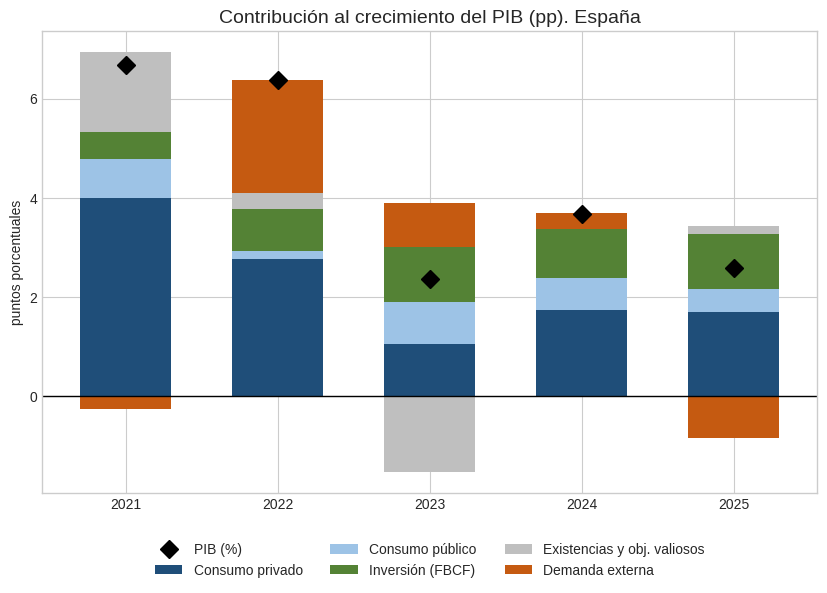

In [19]:
colores = ["#1F4E79", "#9DC3E6", "#548235", "#BFBFBF", "#C55A11"]

fig, ax = plt.subplots(figsize=(10, 6))

# Barras apiladas (todas las columnas menos el PIB)
tabla_anual.drop(columns="PIB").plot(kind="bar", stacked=True, ax=ax, color=colores, width=0.6)

# Crecimiento del PIB con rombos
ax.plot(range(len(tabla_anual)), tabla_anual["PIB"], "D", color="black", markersize=9, label="PIB (%)")

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Contribución al crecimiento del PIB (pp). España", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("puntos porcentuales")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.show()

**Pregunta.** ¿Qué ha tirado del crecimiento en 2025? ¿Y en 2022? ¿Cómo ha cambiado el papel del sector exterior?

### 1.9. ¡Cuidado con este error!

Un error frecuente es calcular los pesos con los **índices de volumen encadenados** (o con los volúmenes encadenados en euros) en lugar de con los datos a **precios corrientes**. Como los volúmenes encadenados **no son aditivos**, las contribuciones así calculadas **no suman** el crecimiento del PIB.

---
## PARTE 2. DATOS TRIMESTRALES

### 2.1. ¿Por qué es más complicado?

La Contabilidad Nacional Trimestral encadena los datos con el método del **solapamiento anual**: los trimestres de un año se valoran a los **precios medios del año anterior**.

Por eso, para calcular la contribución al crecimiento **intertrimestral** hay que distinguir dos casos:

* **Trimestres 2, 3 y 4**: los dos trimestres que comparamos pertenecen al mismo año y están valorados a los mismos precios. La fórmula es parecida a la anual.
* **Trimestre 1**: se compara con el cuarto trimestre del año anterior, que está valorado a precios de otro año. Hay que hacer el cálculo en dos tramos.

### 2.2. Notación

* $X_t$: índice de volumen encadenado del PIB en el trimestre $t$; $X_{i,t}$, el del componente $i$.
* $\bar{X}_{y-1}$ y $\bar{X}_{i,y-1}$: media anual de esos índices en el **año anterior**.
* $w_{i,y-1}$: peso del componente en el PIB en el año anterior, a precios corrientes (sumando los cuatro trimestres). Importaciones con signo negativo.
* $s_{i,y-1}$: peso del componente en el año anterior, pero **medido a precios de dos años antes**:

$$s_{i,y-1} = w_{i,y-2} \times \frac{\bar{X}_{i,y-1} / \bar{X}_{i,y-2}}{\bar{X}_{y-1} / \bar{X}_{y-2}}$$

### 2.3. Las fórmulas

**Trimestres 2, 3 y 4:**

$$C_{i,t} = \frac{\bar{X}_{y-1}}{X_{t-1}} \times w_{i,y-1} \times \frac{X_{i,t} - X_{i,t-1}}{\bar{X}_{i,y-1}}$$

**Trimestre 1:**

$$C_{i,t} = \frac{\bar{X}_{y-1}}{X_{t-1}} \times \left[ w_{i,y-1} \left(\frac{X_{i,t}}{\bar{X}_{i,y-1}} - 1\right) + s_{i,y-1} \left(1 - \frac{X_{i,t-1}}{\bar{X}_{i,y-1}}\right) \right]$$

En el trimestre 1, el primer término recoge el crecimiento desde la media del año anterior hasta el primer trimestre; el segundo, el crecimiento desde el cuarto trimestre del año anterior hasta esa media.

No hace falta memorizarlas: lo importante es entender la idea y seguir los pasos del código.

### 2.4. Importamos los datos del INE

Usamos el fichero de **principales resultados de la Contabilidad Nacional Trimestral** tal y como se descarga del INE (`tabcntr.xlsx`). **Súbelo a Colab** igual que el anual.

Trabajamos con datos **ajustados de estacionalidad y calendario**, que son los que se usan en el análisis de coyuntura. Están en las hojas terminadas en **b**:

* `T1b`: índices de volumen encadenados (2020 = 100).
* `T4b`: precios corrientes (millones de euros).

In [ ]:
fichero_trim = "tabcntr.xlsx"

tabla = pd.read_excel(fichero_trim, sheet_name="T1b", header=None)
tabla.head(20)

Observamos que:

* Los **nombres** de las variables están en la columna **1**.
* Las columnas 3 y 5 son datos **anuales** (2024 y 2025), que no usaremos.
* Los **trimestres** empiezan en la columna 7 y van, de nuevo, en una columna sí y otra no: columnas 7, 9, 11... hasta la 25. Van desde el primer trimestre de 2024 hasta el segundo de 2026.
* El PIB vuelve a aparecer dos veces (demanda y oferta).

Además de los componentes, cogemos la **demanda nacional**, que usaremos al final para comprobar los cálculos.

In [ ]:
tabla.index = tabla[1].str.strip()
tabla = tabla[~tabla.index.duplicated()]

filas_t = ["Producto interior bruto a precios de mercado",
           "Gasto en consumo final de los hogares",
           "Gasto en consumo final de las ISFLSH",
           "Gasto en consumo final de las AAPP",
           "Formación bruta de capital fijo",
           "Exportaciones de bienes y servicios",
           "Importaciones de bienes y servicios",
           "Demanda nacional"]
columnas_t = [7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
periodos = ["2024T1", "2024T2", "2024T3", "2024T4", "2025T1", "2025T2", "2025T3", "2025T4", "2026T1", "2026T2"]
nombres_t = ["PIB", "Consumo_hogares", "Consumo_ISFLSH", "Consumo_AAPP", "FBCF", "Exportaciones", "Importaciones", "Demanda_nacional"]

volumen_t = tabla.loc[filas_t, columnas_t].T
volumen_t.index = periodos
volumen_t.columns = nombres_t
volumen_t = volumen_t.astype(float)

# Añadimos el año y el trimestre (los sacamos del texto del periodo: "2025T3" -> año 2025, trimestre 3)
volumen_t["año"] = volumen_t.index.str[:4].astype(int)
volumen_t["trimestre"] = volumen_t.index.str[-1].astype(int)
volumen_t

In [ ]:
# Repetimos lo mismo con los precios corrientes (hoja T4b)
tabla = pd.read_excel(fichero_trim, sheet_name="T4b", header=None)
tabla.index = tabla[1].str.strip()
tabla = tabla[~tabla.index.duplicated()]

corrientes_t = tabla.loc[filas_t, columnas_t].T
corrientes_t.index = periodos
corrientes_t.columns = nombres_t
corrientes_t = corrientes_t.astype(float)
corrientes_t["año"] = corrientes_t.index.str[:4].astype(int)
corrientes_t["trimestre"] = corrientes_t.index.str[-1].astype(int)
corrientes_t

**Importante.** Cuando el INE publique un nuevo trimestre, el fichero tendrá una columna más: habrá que añadirla a `columnas_t` y a `periodos`. Comprueba siempre en el Excel que las columnas son las correctas.

In [ ]:
# Lista de variables con las que vamos a trabajar (PIB, componentes y demanda nacional)
variables = ["PIB", "Consumo_hogares", "Consumo_ISFLSH", "Consumo_AAPP", "FBCF", "Exportaciones", "Importaciones", "Demanda_nacional"]
componentes = ["Consumo_hogares", "Consumo_ISFLSH", "Consumo_AAPP", "FBCF", "Exportaciones", "Importaciones"]

### 2.5. Paso 1: datos anuales a partir de los trimestrales

Necesitamos tres tablas anuales:

* El valor anual a **precios corrientes** (suma de los cuatro trimestres), para calcular los pesos $w$.
* La **media anual** de los índices de volumen, $\bar{X}$.
* Los pesos $s$.

In [ ]:
# Valor anual a precios corrientes: suma de los trimestres de cada año
corrientes_anual = corrientes_t.groupby("año")[variables].sum()

# Media anual de los índices de volumen
media_anual = volumen_t.groupby("año")[variables].mean()

# Pesos anuales w (a precios corrientes). Importaciones con signo negativo
w_anual = corrientes_anual.div(corrientes_anual["PIB"], axis=0)
w_anual["Importaciones"] = -w_anual["Importaciones"]

w_anual.round(3)

In [ ]:
# Pesos s: peso del año anterior, pero medido a precios de dos años antes
crecimiento_media = media_anual / media_anual.shift(1)        # crecimiento de la media anual de cada variable
crecimiento_relativo = crecimiento_media.div(crecimiento_media["PIB"], axis=0)   # respecto al del PIB
s_anual = w_anual.shift(1) * crecimiento_relativo

s_anual.round(3)

### 2.6. Paso 2: llevamos los datos del año anterior a cada trimestre

Las fórmulas usan, para cada trimestre, datos del **año anterior** ($w_{y-1}$, $s_{y-1}$, $\bar{X}_{y-1}$). Creamos tablas trimestrales donde cada fila contiene esos datos del año anterior.

In [ ]:
# Año anterior de cada trimestre
año_anterior = volumen_t["año"] - 1

# reindex busca, para cada trimestre, la fila del año anterior en la tabla anual
w = w_anual.reindex(año_anterior)
s = s_anual.reindex(año_anterior)
media = media_anual.reindex(año_anterior)

# Ponemos como índice los trimestres, para que coincida con volumen_t
w.index = volumen_t.index
s.index = volumen_t.index
media.index = volumen_t.index

media.tail()

### 2.7. Paso 3: aplicamos las fórmulas

In [ ]:
X = volumen_t[variables]          # índice del trimestre actual
X_ant = X.shift(1)                # índice del trimestre anterior

# Factor común a las dos fórmulas: media del PIB del año anterior / PIB del trimestre anterior
factor = media["PIB"] / X_ant["PIB"]

# Fórmula para los trimestres 2, 3 y 4
contrib_T2_T4 = w * (X - X_ant) / media
contrib_T2_T4 = contrib_T2_T4.mul(factor, axis=0) * 100

# Fórmula para el trimestre 1
contrib_T1 = w * (X / media - 1) + s * (1 - X_ant / media)
contrib_T1 = contrib_T1.mul(factor, axis=0) * 100

In [ ]:
# Combinamos: usamos la fórmula del trimestre 1 solo en las filas del primer trimestre
es_T1 = volumen_t["trimestre"] == 1

contrib_trim = contrib_T2_T4.copy()
contrib_trim.loc[es_T1] = contrib_T1.loc[es_T1]

# Eliminamos las filas que no se pueden calcular (vacías): todo 2024 y el primer trimestre de 2025,
# porque necesitan datos de años anteriores que no están en el fichero
contrib_trim = contrib_trim.dropna()

contrib_trim.round(2)

### 2.8. Existencias, demanda nacional y demanda externa

Igual que con los datos anuales, la contribución de las existencias (y objetos valiosos) se obtiene como residuo.

In [ ]:
# Crecimiento intertrimestral del PIB (%)
crecimiento_pib_t = volumen_t["PIB"].pct_change() * 100

# Existencias y objetos valiosos, por residuo
contrib_trim["Existencias"] = crecimiento_pib_t - contrib_trim[componentes].sum(axis=1)

# Demanda externa
contrib_trim["Demanda_externa"] = contrib_trim["Exportaciones"] + contrib_trim["Importaciones"]

contrib_trim[["Existencias", "Demanda_externa"]].round(2)

**Comprobación.** Hemos calculado la contribución de la demanda nacional de dos formas distintas:

1. **Directamente**, aplicando la fórmula a su propio índice (columna `Demanda_nacional` de `contrib_trim`).
2. **Sumando** las contribuciones de sus componentes (consumo, FBCF y existencias).

Si todo está bien, deben coincidir.

In [ ]:
comprobacion = pd.DataFrame()
comprobacion["Directa"] = contrib_trim["Demanda_nacional"]
comprobacion["Suma de componentes"] = (contrib_trim["Consumo_hogares"] + contrib_trim["Consumo_ISFLSH"]
                                       + contrib_trim["Consumo_AAPP"] + contrib_trim["FBCF"]
                                       + contrib_trim["Existencias"])
comprobacion.round(3)

**Nota sobre la desestacionalización.** El INE desestacionaliza cada serie por separado, así que los componentes corregidos de estacionalidad no suman exactamente el total. Esa pequeña discrepancia queda recogida en el residuo de existencias. Por eso conviene interpretar la contribución de las existencias con cautela.

### 2.9. Gráfico

In [ ]:
tabla_trim = pd.DataFrame()
tabla_trim["Consumo privado"] = contrib_trim["Consumo_hogares"] + contrib_trim["Consumo_ISFLSH"]
tabla_trim["Consumo público"] = contrib_trim["Consumo_AAPP"]
tabla_trim["Inversión (FBCF)"] = contrib_trim["FBCF"]
tabla_trim["Existencias y obj. valiosos"] = contrib_trim["Existencias"]
tabla_trim["Demanda externa"] = contrib_trim["Demanda_externa"]
tabla_trim["PIB"] = crecimiento_pib_t

tabla_trim = tabla_trim.dropna()

fig, ax = plt.subplots(figsize=(10, 6))
tabla_trim.drop(columns="PIB").plot(kind="bar", stacked=True, ax=ax, color=colores, width=0.6)
ax.plot(range(len(tabla_trim)), tabla_trim["PIB"], "D", color="black", markersize=9, label="PIB (%)")

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Contribución al crecimiento intertrimestral del PIB (pp). España", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("puntos porcentuales")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.show()

**Pregunta.** ¿Qué componentes explican el crecimiento del último trimestre? ¿Se parece al patrón anual?